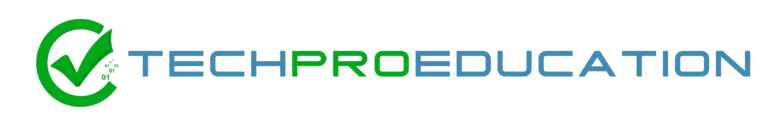

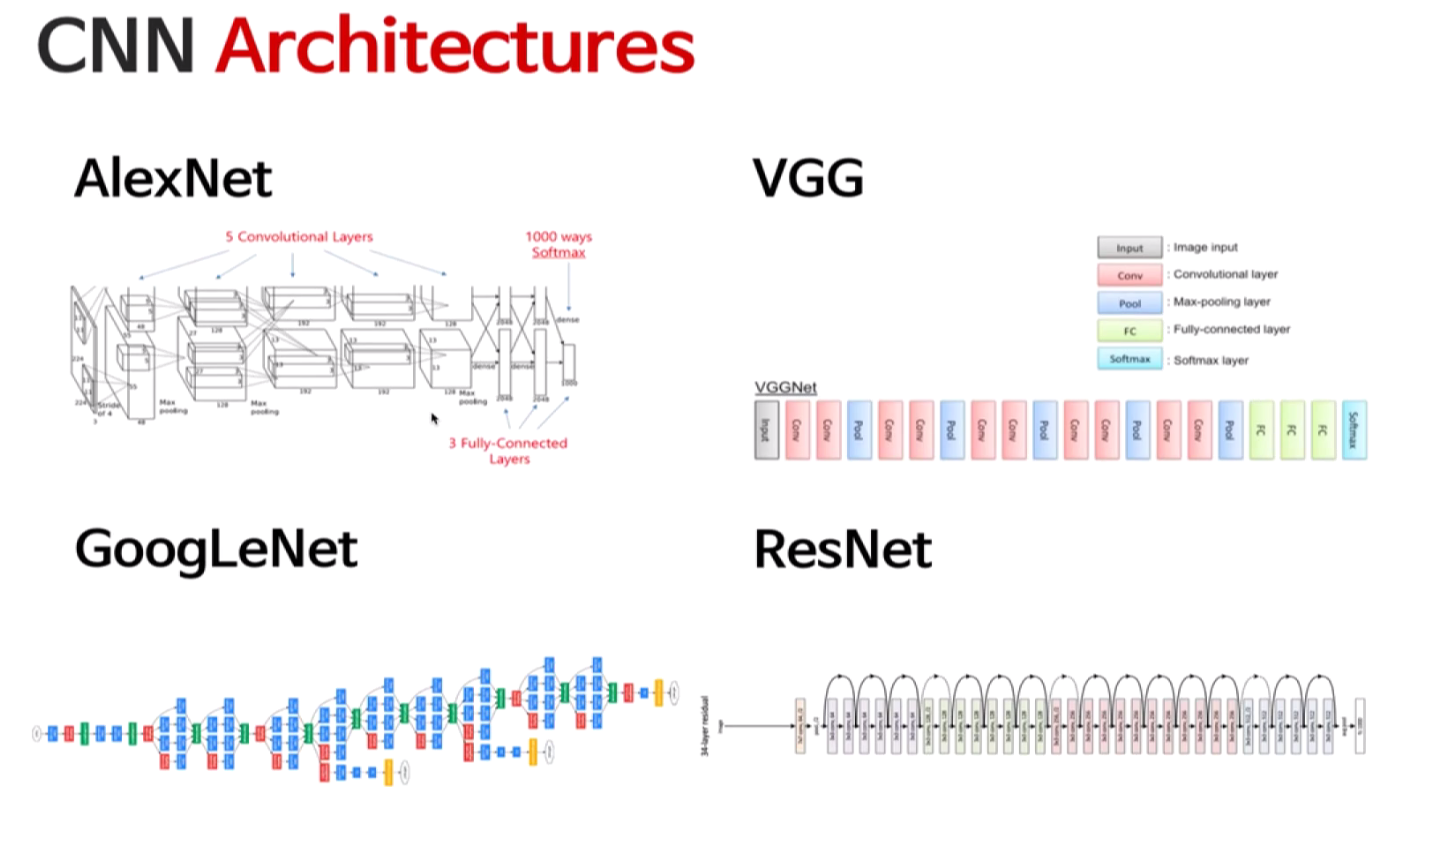

In [50]:
import os
import pandas as pd
import tensorflow as tf
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.image import imread

In [51]:
os.getcwd()

'C:\\Users\\jawed\\Desktop\\B287 DL\\04 CNN\\Repo Notebooks\\06 Transfer Learning Cats & Dogs'

The Dogs vs. Cats dataset is a common computer vision dataset in which pictures are classified as either including a dog or a cat.

After the dataset is well studied, it can be used to understand and practice how to design, evaluate, and apply convolutional neural networks for image classification.

You will build a classifier with images and try to detect dogs versus cats using CNN.

Train set includes 12500 cat-5026 dog images, validation set includes 1219 cat-1071 dog images and test set incgludes 6897 cat and dogs images together. 

In [52]:
my_data_dir='datam/'

In [53]:
os.listdir(my_data_dir)

['test', 'train']

In [54]:
train_path = my_data_dir+'train'
test_path = my_data_dir+'test'

In [55]:
os.listdir(train_path)

['cat', 'dog']

**Let's check how many images there are.**

In [56]:
len(os.listdir(train_path+'/cat'))

12500

In [57]:
len(os.listdir(train_path+'/dog'))

5026

In [58]:
os.listdir(train_path+'/cat')[0]

'cat.0.jpg'

In [59]:
path1=train_path+'/cat'+'/cat.1000.jpg'
path2=train_path+'/dog'+'/dog.1000.jpg'

In [60]:
cat_img=imread(path1)
dog_img=imread(path2)

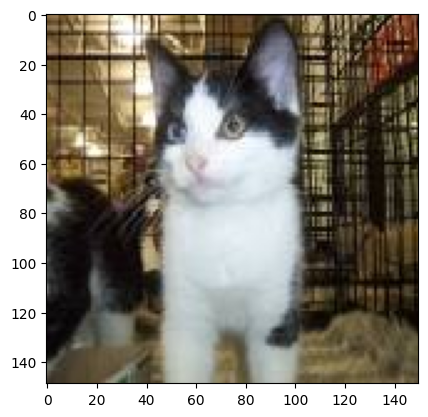

In [61]:
plt.imshow(cat_img)

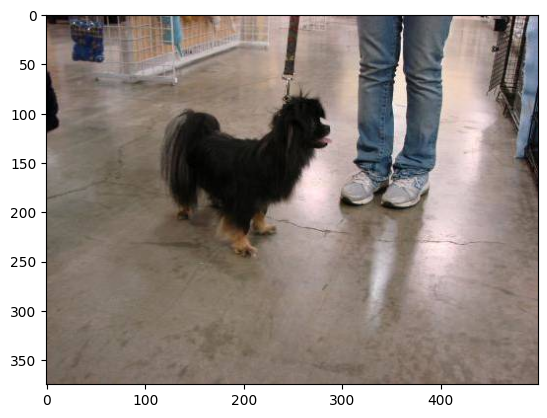

In [62]:
plt.imshow(dog_img)

**Let's decide on the final dimension of these images.**

In [63]:
cat_img.max()

np.uint8(255)

In [64]:
cat_img.min()

np.uint8(0)

In [65]:
cat_img.shape

(149, 150, 3)

In [66]:
dog_img.shape

(375, 499, 3)

In [67]:
x= []
y = []
for image in os.listdir(train_path+'/cat'):
    
    img = imread(train_path+'/cat/'+image)
    d1,d2,colors = img.shape
    x.append(d1)
    y.append(d2)

<Axes: >

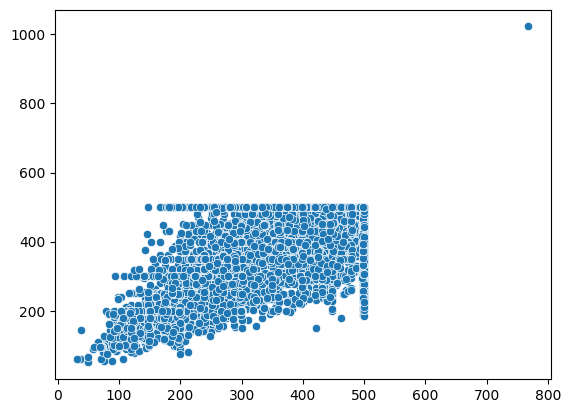

In [68]:
sns.scatterplot(x=x,y=y)

In [69]:

np.mean(x)

np.float64(356.46712)

In [70]:
np.mean(y)

np.float64(410.52264)

In [71]:
image_shape = (224, 224,3)

In [72]:
# help(ImageDataGenerator)

**Image Manipulation**

We can use the ImageDataGenerator to manipulate the images with rotation, resizing, and scaling so the model becomes more robust to different images that our data set doesn't have. ImageDataGenerator does the followings.

* Accepts a batch of images used for training.
* Applies a series of random transformations to each image in the batch.
* Replaces the original batch with randomly transformed batch.
* Training the CNN on this randomly transformed batch.

The goal of applying data augmentation is to have a more generalized model.

In [73]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import preprocess_input # For preprocessing (rescaling)

In [74]:
image_gen = ImageDataGenerator(rotation_range=20, # rotate the image 20 degrees
                               width_shift_range=0.10, # Shift the pic width by a max of 10%
                               height_shift_range=0.10, # Shift the pic height by a max of 10%
                               
                               # rescale=1/255, # Rescale the image by normalzing it.
                               preprocessing_function=preprocess_input,  # Apply ResNet preprocessing here - ISMET
                               
                               shear_range=0.1, # Shear means cutting away part of the image (max 10%)
                               zoom_range=0.1, # Zoom in by 10% max
                               horizontal_flip=True, # Allo horizontal flipping
                               fill_mode='nearest' # Fill in missing pixels with the nearest filled value
                              )

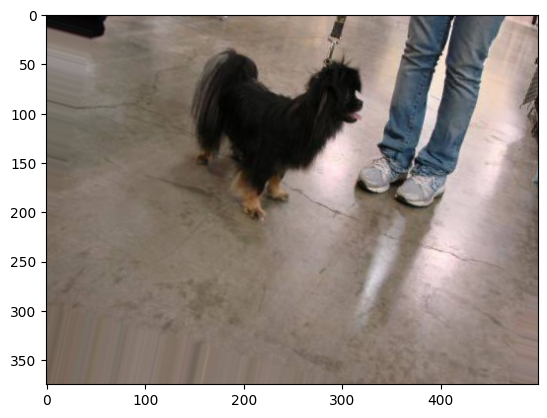

In [75]:
plt.imshow(image_gen.random_transform(dog_img))

image_gen.flow_from_directory(train_path)

# Creating the Model

In [76]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dropout, Flatten, Dense, Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.applications.resnet import ResNet152, preprocess_input, decode_predictions

In transfer learning models; 

1) **include_top=False** --> We are setting up the ANN part.

2) **weights= "imagenet"** --> Use the weights learned while training on imageNet data.

3) **layer.trainable=False** --> The model doesn't trained from scratch, the weights it has previously learned should be used.

In [77]:
from keras.applications.vgg16 import VGG16

In [78]:
resnet_model = Sequential()

pretrained_model= tf.keras.applications.resnet.ResNet152(include_top=False,
                   input_shape=image_shape,
                   pooling='avg',
                   weights= "imagenet")

for layer in pretrained_model.layers:
        layer.trainable=False  # Don't train model again.

resnet_model.add(pretrained_model)

# Flatten
resnet_model.add(Flatten())

# ANN
# Hidden Layer
resnet_model.add(Dense(64, activation='relu'))

# Output layer
resnet_model.add(Dense(1, activation='sigmoid'))

# Compile the Model
resnet_model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [79]:
resnet_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet152 (Functional)               │ (None, 2048)                │      58,370,944 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │         131,136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 58,502,145 (223.17 MB)

 Trainable params: 131,201 (512.50 KB)

 Non-trainable params: 58,370,944 (222.67 MB)

## Early Stopping

In [80]:
from tensorflow.keras.callbacks import EarlyStopping

In [81]:
early_stop = EarlyStopping(monitor='val_loss',patience=3)

In [82]:
batch_size = 64

In [83]:
train_image_gen = image_gen.flow_from_directory(train_path,
                                               target_size=(224, 224),
                                               color_mode='rgb',
                                               batch_size=batch_size,
                                               class_mode='binary', shuffle=True)

Found 17526 images belonging to 2 classes.


In [84]:
image_gen_test = ImageDataGenerator(rescale=1/255)

test_image_gen = image_gen_test.flow_from_directory(test_path,

                                                   target_size=(224, 224),
                                                   
                                                   color_mode='rgb',
                                                   
                                                   batch_size=batch_size,
                                                   
                                                   class_mode='binary', shuffle=False)

Found 2290 images belonging to 2 classes.


## Model Training

In [85]:
results = resnet_model.fit(train_image_gen,epochs=5,
                    validation_data=test_image_gen,
                    callbacks=[early_stop])

C:\Users\jawed\anaconda3\envs\B287CNNCV\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
274/274 ━━━━━━━━━━━━━━━━━━━━ 3219s 12s/step - accuracy: 0.9483 - loss: 0.1165 - val_accuracy: 0.5323 - val_loss: 1.4956
Epoch 2/5
274/274 ━━━━━━━━━━━━━━━━━━━━ 3585s 13s/step - accuracy: 0.9862 - loss: 0.0400 - val_accuracy: 0.5323 - val_loss: 1.4529
Epoch 3/5
274/274 ━━━━━━━━━━━━━━━━━━━━ 2654s 10s/step - accuracy: 0.9910 - loss: 0.0255 - val_accuracy: 0.5323 - val_loss: 1.4288
Epoch 4/5
274/274 ━━━━━━━━━━━━━━━━━━━━ 1816s 7s/step - accuracy: 0.9922 - loss: 0.0235 - val_accuracy: 0.5323 - val_loss: 1.6250
Epoch 5/5
274/274 ━━━━━━━━━━━━━━━━━━━━ 1808s 7s/step - accuracy: 0.9934 - loss: 0.0171 - val_accuracy: 0.5323 - val_loss: 2.6131


# Evaluating the Model

In [86]:
summary = pd.DataFrame(resnet_model.history.history)
summary.head()

,accuracy,loss,val_accuracy,val_loss
0,0.978147,0.056196,0.532314,1.495646
1,0.989159,0.032839,0.532314,1.452906
2,0.990642,0.026171,0.532314,1.428801
3,0.992582,0.021969,0.532314,1.625048
4,0.992982,0.019336,0.532314,2.613066


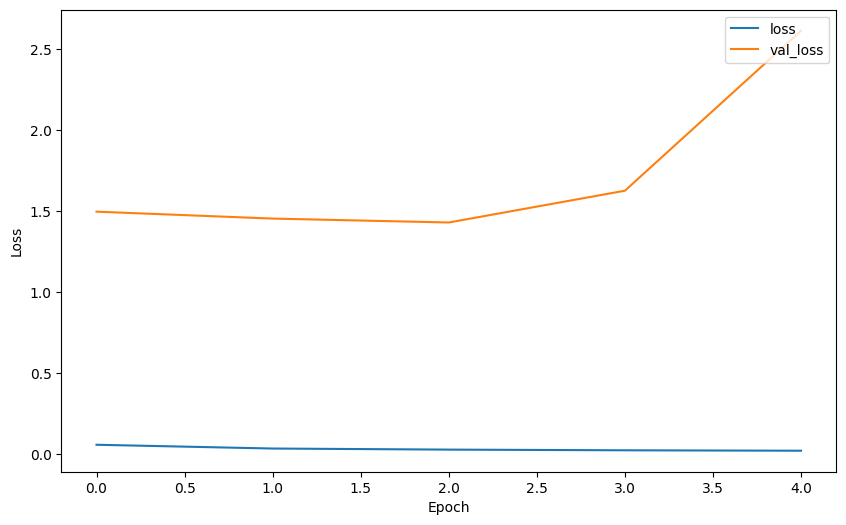

In [87]:
plt.figure(figsize=(10,6))
plt.plot(summary.loss, label="loss")
plt.plot(summary.val_loss, label="val_loss")
plt.legend(loc="upper right")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.show()

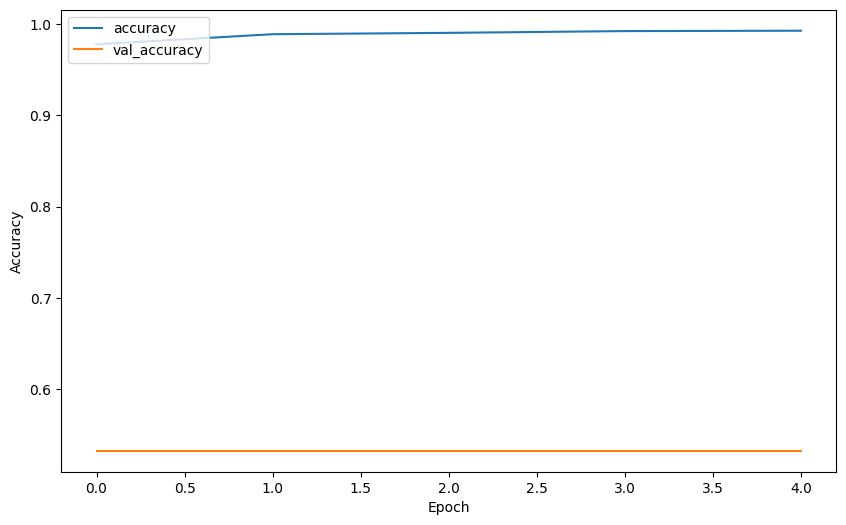

In [88]:
plt.figure(figsize=(10,6))
plt.plot(summary.accuracy, label="accuracy")
plt.plot(summary.val_accuracy, label="val_accuracy")
plt.legend(loc="upper left")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.show()

In [89]:
resnet_model.metrics_names

['loss', 'compile_metrics']

In [90]:
resnet_model.evaluate(test_image_gen)

36/36 ━━━━━━━━━━━━━━━━━━━━ 206s 6s/step - accuracy: 0.8507 - loss: 0.8367


[2.6130659580230713, 0.5323144197463989]

In [91]:
pred_probabilities = resnet_model.predict(test_image_gen)

36/36 ━━━━━━━━━━━━━━━━━━━━ 215s 6s/step


In [92]:
pred_probabilities

array([[0.00458944],
       [0.00418725],
       [0.00319395],
       ...,
       [0.00248803],
       [0.00389465],
       [0.00417005]], dtype=float32)

In [93]:
test_image_gen.classes[:50]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0], dtype=int32)

In [94]:
predictions = pred_probabilities > 0.5

In [95]:
predictions[:50]

array([[False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False]])

In [96]:
from sklearn.metrics import classification_report,confusion_matrix

In [97]:
print(classification_report(test_image_gen.classes,predictions))

              precision    recall  f1-score   support

           0       0.53      1.00      0.69      1219
           1       0.00      0.00      0.00      1071

    accuracy                           0.53      2290
   macro avg       0.27      0.50      0.35      2290
weighted avg       0.28      0.53      0.37      2290



C:\Users\jawed\anaconda3\envs\B287CNNCV\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\jawed\anaconda3\envs\B287CNNCV\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\jawed\anaconda3\envs\B287CNNCV\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", 

In [98]:
confusion_matrix(test_image_gen.classes,predictions)

array([[1219,    0],
       [1071,    0]])

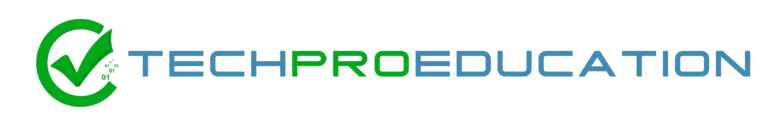